
------------------------
Processing Node ID: 1
     Bound      Capacity   Solution
UB:  17.3       15.0       [0.5833333333333334, 1.0, 1.0, 1.0, 1.0]
LB:  15.0       8.0        [0.0, 1.0, 1.0, 1.0, 1.0]
New best feasible solution (LB*) found, since LB > LB* (15.0 > -Inf)!

------------------------
Processing Node ID: 3
     Bound      Capacity   Solution
UB:  11.5       15.0       [1.0, 0.0, 0.75, 0.0, 0.0]
LB:  8.0        15.0       [1.0, 1.0, 0.0, 1.0, 0.0]
Pruned by bounding, since UB < LB* (11.5 < 15.0)

------------------------
Processing Node ID: 2
     Bound      Capacity   Solution
UB:  15.0       8.0        [-0.0, 1.0, 1.0, 1.0, 1.0]
LB:  15.0       8.0        [0.0, 1.0, 1.0, 1.0, 1.0]
Pruned by optimality, since UB ≈ LB* (15.0 ≈ 15.0)

Best solution found:
- Value: 15.0
- Quantity: [0, 1, 1, 1, 1]
- Capacity used: 8.0


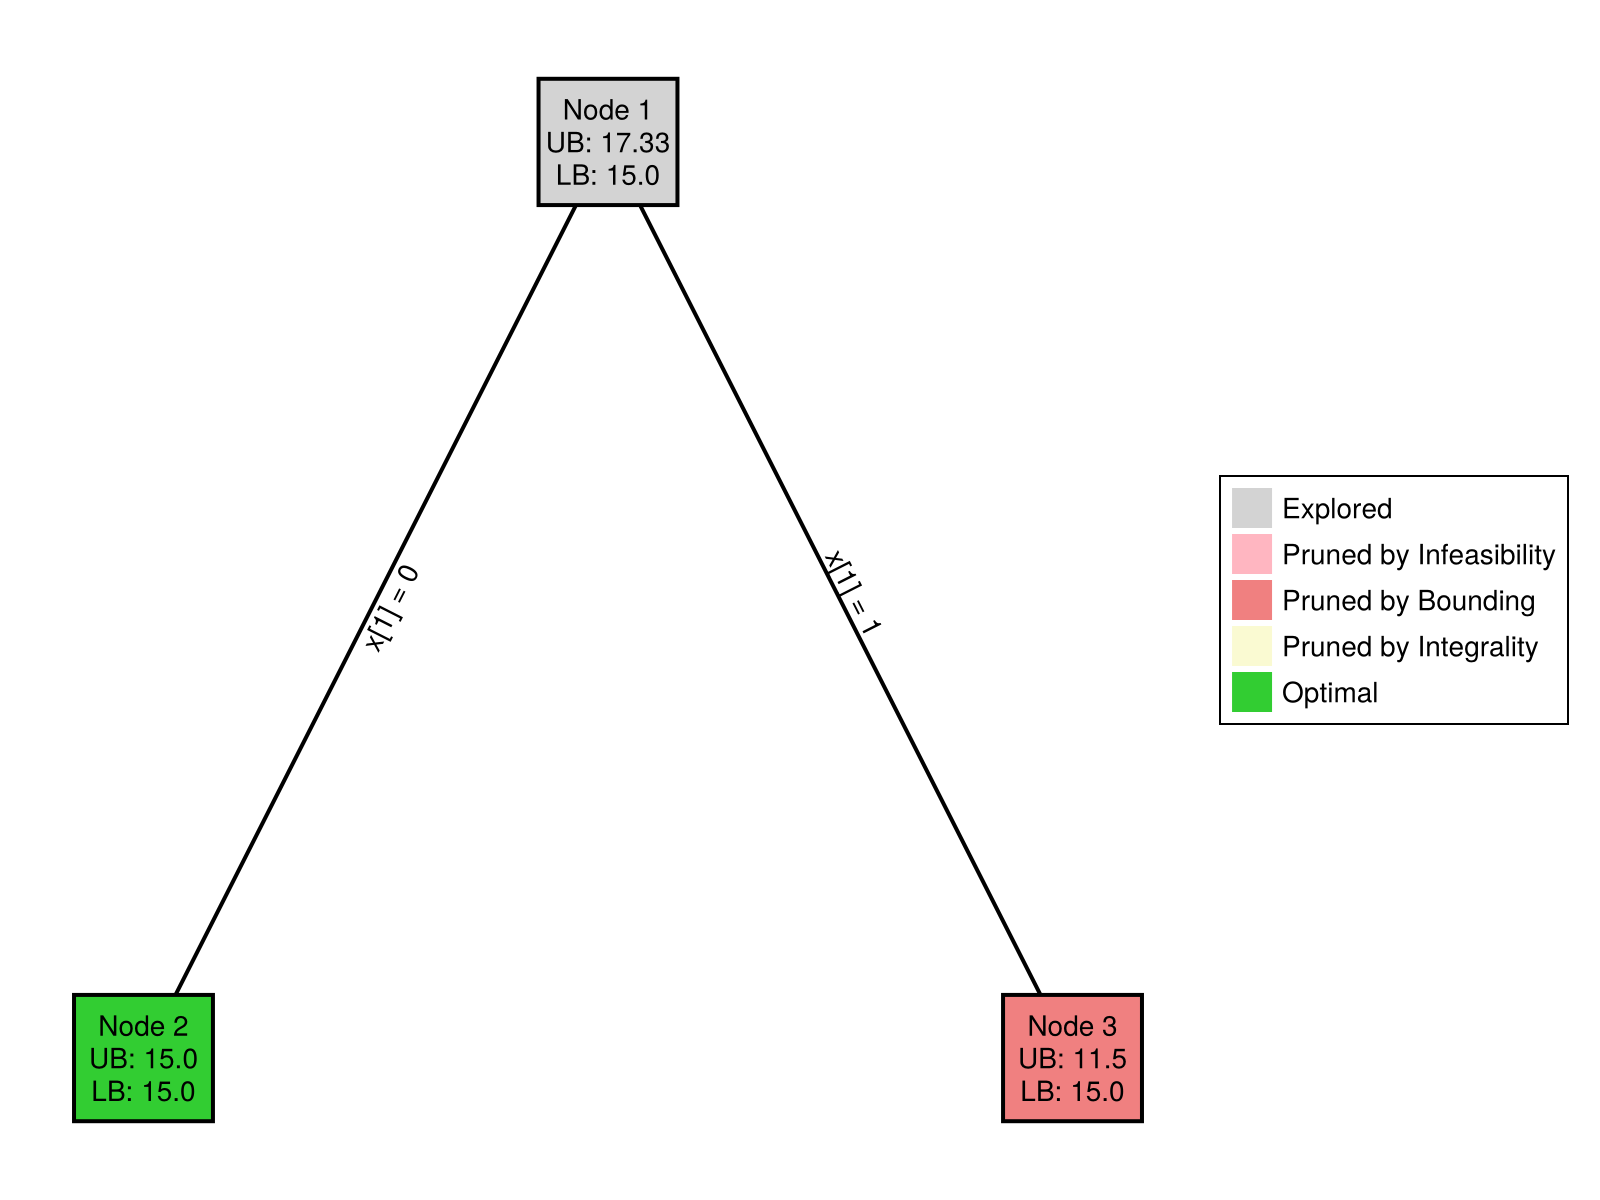

In [2]:
# -------------------------------------------------------------
#  Code for: "Introduction to Integer Programming and Applications with Julia"
#  Chapter: 8 – Branch and Bound
#  Section: Exercise 1.1
#  Author(s): Luiz Henrique Nogueira Lorena
# -------------------------------------------------------------

using JuMP, HiGHS, Graphs, MetaGraphs, Printf
using NetworkLayout, Makie, CairoMakie, GraphMakie, Colors

struct ProblemData
    v::Vector{Float64}       # Values of items
    w::Vector{Float64}       # Weights of items
    W::Float64               # Capacity of the knapsack
    item_order::Vector{Int}  # Order of items based on value-to-weight ratio
end

function plot_bnb_tree(graph)
    status_colors = Dict(
        :explored => colorant"lightgray",
        :pruned_by_infeasibility => colorant"lightpink",
        :pruned_by_bounding => colorant"lightcoral",
        :pruned_by_integrality => colorant"lightgoldenrodyellow",
        :optimal => colorant"limegreen"
    )
    node_labels = String[]
    for v in vertices(graph)
        ub = round(get_prop(graph, v, :ub), digits=2)
        lb = round(get_prop(graph, v, :lb), digits=2)
        base_label = "Node $(v)\nUB: $(ub)\nLB: $(lb)"
        push!(node_labels, base_label)
    end
    edge_labels = [get_prop(graph, e, :label) for e in edges(graph)]
    node_colors = [get(status_colors, get_prop(graph, v, :state), colorant"gray") for v in vertices(graph)]

    # Use a scalar for node_size, not a tuple
    node_size = (110,100)

    f, ax, p = GraphMakie.graphplot(graph,
        layout=NetworkLayout.Buchheim(),
        nlabels=node_labels,
        nlabels_fontsize=14,
        elabels_fontsize=14,
        node_color=node_colors,
        arrow_show=false,
        node_marker=:rect,
        node_size=node_size,
        node_strokewidth=2,
        node_strokecolor=:black,
        elabels=edge_labels, elabels_textsize=10,
        nlabels_align=(:center, :center), nlabels_textsize=10,
        edge_width=2, figure=(; size=(800, 600))
    )

    hidedecorations!(ax)
    hidespines!(ax)

    # Add margins to the plot
    ax.leftspinevisible = false
    ax.rightspinevisible = false
    ax.topspinevisible = false
    ax.bottomspinevisible = false
    ax.xautolimitmargin[] = (0.12, 0.12)
    ax.yautolimitmargin[] = (0.12, 0.12)

    # Create a legend
    elements = [
        PolyElement(color=status_colors[:explored]),
        PolyElement(color=status_colors[:pruned_by_infeasibility]),
        PolyElement(color=status_colors[:pruned_by_bounding]),
        PolyElement(color=status_colors[:pruned_by_integrality]),
        PolyElement(color=status_colors[:optimal])
    ]

    labels = [
        "Explored",
        "Pruned by Infeasibility",
        "Pruned by Bounding",
        "Pruned by Integrality",
        "Optimal"
    ]

    legend = Legend(f[1, 2], elements, labels; tellheight=false)
    f[1, 1] = ax
    f[1, 2] = legend

    return f
end

function UB(data, node)
    n = length(data.w)
    model = Model(HiGHS.Optimizer)
    set_silent(model)
    @variable(model, 0 <= x[1:n] <= 1)
    @objective(model, Max, sum(data.v[i] * x[i] for i in 1:n))
    @constraint(model, sum(data.w[i] * x[i] for i in 1:n) <= data.W)
    for (fixed_id, fixed_value) in node[:fixed_values]
        @constraint(model, x[fixed_id] == fixed_value)
    end
    optimize!(model)
    if termination_status(model) == MOI.OPTIMAL
        solution = value.(x)
        first_not_full = findfirst(x -> 0 < x < 1, solution)
        return objective_value(model), solution, first_not_full
    else
        return nothing, nothing, nothing
    end
end

function LB(data, node)
    n = length(data.w)
    solution = zeros(n)
    total_weight = 0
    for (fixed_id, fixed_value) in node[:fixed_values]
        if total_weight + data.w[fixed_id] * fixed_value > data.W
            return nothing, nothing
        end
        solution[fixed_id] = fixed_value
        total_weight += data.w[fixed_id] * fixed_value
    end
    remaining_items = filter(id -> !(id in keys(node[:fixed_values])), data.item_order)
    for id in remaining_items
        if total_weight + data.w[id] <= data.W
            total_weight += data.w[id]
            solution[id] = 1
        end
    end
    return sum(solution .* data.v), solution
end

function knap_bnb(data::ProblemData)

    # Nodes and edges for the branch-and-bound tree
    graph = MetaDiGraph()
    add_vertex!(graph)
    root = Dict(:id => 1,
                :ub => Inf,
                :lb => -Inf,
                :fixed_values => Dict(),
                :state => :explored)
    set_props!(graph, 1, root)

    # Set initial best
    set_prop!(graph, :best_lb, -Inf)
    set_prop!(graph, :best_lb_sol, [])

    # Active nodes to process
    active_nodes = [root]

    while !isempty(active_nodes)
        
        current_node = pop!(active_nodes)

        println("\n------------------------")
        println("Processing Node ID: ", current_node[:id])

        ub, sol, branch_id = UB(data, current_node)
        lb, heu = LB(data, current_node)

        @printf("%-4s %-10s %-10s %s\n", "", "Bound", "Capacity", "Solution")
        @printf("%-4s %-10s %-10s %s\n", "UB:", isnothing(ub) ? "N/A" : @sprintf("%.1f", ub), 
                                                isnothing(sol) ? "N/A" : sum(sol .* data.w), 
                                                isnothing(sol) ? "N/A" : string(sol))
        @printf("%-4s %-10s %-10s %s\n", "LB:", isnothing(lb) ? "N/A" : @sprintf("%.1f", lb), 
                                                isnothing(heu) ? "N/A" : sum(heu .* data.w), 
                                                isnothing(heu) ? "N/A" : string(heu))

        # Pruning conditions
        if isnothing(lb) || isnothing(ub)
            println("Pruned, since is infeasible.")
            current_node[:ub] = Inf
            current_node[:lb] = get_prop(graph, :best_lb)
            current_node[:state] = :pruned_by_infeasibility
            set_props!(graph, current_node[:id], current_node)
            continue
        elseif lb > get_prop(graph, :best_lb)
            println("New best feasible solution (LB*) found, since LB > LB* ($lb > $(get_prop(graph, :best_lb)))!")
            set_prop!(graph, :best_lb, lb)
            set_prop!(graph, :best_lb_sol, heu)
        end

        # Update the state of the current node
        current_node[:ub] = ub
        current_node[:lb] = get_prop(graph, :best_lb)   
        set_props!(graph, current_node[:id], current_node)

        if ub < get_prop(graph, :best_lb)
            println("Pruned by bounding, since UB < LB* ($ub < $(get_prop(graph, :best_lb)))")
            current_node[:state] = :pruned_by_bounding
            set_props!(graph, current_node[:id], current_node)
            continue
        elseif !isnothing(ub) && abs(ub - get_prop(graph, :best_lb)) < 1e-6
            println("Pruned by optimality, since UB ≈ LB* ($ub ≈ $(get_prop(graph, :best_lb)))")
            current_node[:state] = :optimal
            set_props!(graph, current_node[:id], current_node)
            continue
        elseif isnothing(branch_id)
            println("Pruned by integrality, since no branching variable found.")
            current_node[:state] = :pruned_by_integrality
            set_props!(graph, current_node[:id], current_node)
            continue
        end
        
        # -- Branching ---
        for branch in [:left, :right]
            add_vertex!(graph)
            child_id = nv(graph)
            child_fixed_values = copy(current_node[:fixed_values])
            edge_label = ""
            if branch == :left
                child_fixed_values[branch_id] = 0
                edge_label = "x[$branch_id] = 0"
            else
                child_fixed_values[branch_id] = 1
                edge_label = "x[$branch_id] = 1"
            end
            child_prop = Dict(:id => child_id,
                              :ub => Inf,
                              :lb => get_prop(graph, :best_lb),
                              :fixed_values => child_fixed_values,
                              :state => :explored)
            set_props!(graph, child_id, child_prop)
            add_edge!(graph, current_node[:id], child_id)
            set_prop!(graph, current_node[:id], child_id, :label, edge_label)
            push!(active_nodes, child_prop)
        end        
    end
    return graph
end

# --- Main Execution ---
v = [4, 2, 10, 2, 1]
w = [12, 2, 4, 1, 1]
W = 15
item_order = sortperm(v ./ w, rev=true)
data = ProblemData(v, w, W, item_order)

# Run the branch-and-bound algorithm
graph = knap_bnb(data)

println("\n========================")
println("Best solution found:")
println("- Value: ", get_prop(graph, :best_lb))
println("- Quantity: ", Int.(get_prop(graph, :best_lb_sol)))
println("- Capacity used: ", sum(get_prop(graph, :best_lb_sol) .* data.w))

# objective, solution, capacity, graph = knap_bnb(data)
plot_bnb_tree(graph)